In [1]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import scipy.stats
%matplotlib inline

In [14]:
#Multiple mice
import pickle

# Load the pickle file
with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

animal = 'astroM10'

fc_traces = collection_fc.animals[animal].accepted_traces.to_numpy()

In [15]:
fc_traces

array([[ 4.37204052e-03,  4.59668786e-03,  3.20258957e-03, ...,
         8.39634541e-04,  3.78661941e-03,  3.69150633e-03],
       [ 2.89504351e-03,  2.91366034e-03,  1.42269593e-03, ...,
        -1.34701581e-04,  3.95752146e-03,  2.84616473e-03],
       [ 3.29039415e-03,  2.95152254e-03,  2.01654834e-03, ...,
         2.76972466e-04,  5.04664527e-03,  3.55276928e-03],
       ...,
       [ 1.16723255e-03,  6.66874430e-04,  6.65055231e-04, ...,
        -1.05155221e-06,  7.97610882e-04,  5.51062766e-04],
       [ 1.82566554e-03,  5.22558055e-04,  2.17747071e-03, ...,
        -2.61067779e-04,  1.20391250e-03,  1.09187928e-03],
       [ 1.95609044e-03,  2.93149735e-04,  1.63714173e-03, ...,
         7.14885620e-04,  1.52218469e-03,  1.18209558e-03]])

In [16]:
fc_df = fc_traces[:3303,:].T
fc_df

array([[ 0.00437204,  0.00289504,  0.00329039, ...,  0.0024173 ,
         0.00259586,  0.00288221],
       [ 0.00459669,  0.00291366,  0.00295152, ...,  0.00108361,
         0.00027802,  0.00125354],
       [ 0.00320259,  0.0014227 ,  0.00201655, ...,  0.00209607,
         0.00234485,  0.00396372],
       ...,
       [ 0.00083963, -0.0001347 ,  0.00027697, ...,  0.00092158,
         0.0024502 ,  0.0009783 ],
       [ 0.00378662,  0.00395752,  0.00504665, ...,  0.00255701,
         0.00240149,  0.00305783],
       [ 0.00369151,  0.00284616,  0.00355277, ...,  0.00148313,
         0.00140018,  0.00085255]])

In [17]:
across_eta_, time = onep.eta_individual_cells(
    data=fc_df,
    timestamps=collection_fc.animals[animal].Timestamps[:3303, ].to_numpy().squeeze(),
    events=[[120, 180, 240, 300], ],  #detected onsets
    window=28
)

In [18]:
mu_fc = pd.read_csv("/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/rui_modeling_plots_csv/astrocyte_shot_Gaussian_noise3_all.csv")
mu_fc

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal
0,1,0.0,0.0,2.6,0.5,0.5,0.512348,2.675,2.6,2.9,2.0,3.2,1,F3.
1,10,0.0,0.0,2.3,0.8,0.6,0.493288,2.350,2.3,2.3,1.8,3.0,10,F3.
2,100,0.0,0.0,13.0,8.1,0.8,2.459505,5.325,7.1,4.2,7.6,2.4,100,F3.
3,1000,0.1,0.0,3.2,0.8,0.3,0.287228,3.175,3.1,3.0,3.0,3.6,1000,F9.
4,1001,0.1,0.0,3.7,1.3,0.2,0.330404,3.625,3.2,3.7,3.6,4.0,1001,F9.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3080,995,0.1,0.0,4.1,0.9,1.5,1.797220,3.850,2.4,2.4,4.5,6.1,995,F9.
3081,996,0.1,0.0,3.2,1.1,0.2,0.000000,3.200,3.2,3.2,3.2,3.2,996,F9.
3082,997,0.1,0.0,3.2,0.9,0.5,0.408248,3.200,3.3,2.6,3.4,3.5,997,F9.
3083,998,0.2,0.0,5.6,2.2,0.2,0.320156,5.675,5.8,5.2,5.9,5.8,998,F9.


In [19]:
animal_to_filter = ['M10']

# Use .isin() to filter the DataFrame
mu_fc_animal = mu_fc[mu_fc['animal'].isin(animal_to_filter)]
mu_fc_animal

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal
2125,2912,0.2,0.0,3.1,0.8,0.5,0.579511,2.975,2.2,3.0,3.1,3.6,2912,M10
2126,2913,0.0,0.0,3.4,1.1,1.1,0.994987,3.450,2.3,3.6,3.2,4.7,2913,M10
2127,2914,0.0,0.0,2.9,0.9,0.6,0.704154,3.075,2.5,2.9,2.8,4.1,2914,M10
2128,2915,0.1,0.0,3.5,1.0,0.5,0.516398,3.500,2.9,4.1,3.3,3.7,2915,M10
2129,2916,0.1,0.0,5.6,1.5,4.9,2.921757,4.150,2.2,2.9,3.0,8.5,2916,M10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2314,3082,0.0,0.0,2.3,0.8,0.2,0.244949,2.300,2.0,2.3,2.3,2.6,3082,M10
2315,3083,0.0,0.0,3.1,0.9,0.5,0.537742,3.025,2.4,2.9,3.1,3.7,3083,M10
2316,3084,0.0,0.0,2.5,0.8,0.5,0.535413,2.600,2.0,2.6,2.5,3.3,3084,M10
2317,3085,0.0,0.0,2.8,0.9,0.5,0.478714,2.825,2.4,2.8,2.6,3.5,3085,M10


In [21]:
mu_fc_animal = mu_fc_animal.iloc[:, :]
mu_fc_animal['across_eta_fc'] = across_eta_.tolist()

ValueError: Length of values (175) does not match length of index (174)

In [64]:
sorted = mu_fc_animal.sort_values(by='pred_mu')
sorted

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal,orig_index,across_eta_fc
780,339.0,0.1,0.0,1.8,0.7,0.3,NaN,NaN,9.1,10.3,7.9,3.1,34,astro3,33,"[0.006552209360097702, 0.007050946772406435, 0..."
1390,889.0,0.1,0.0,2.0,0.9,0.8,NaN,NaN,5.2,4.2,2.1,8.5,89,astro3,89,"[0.0055110204796480645, 0.00528971803046777, 0..."
585,163.0,0.0,0.0,2.0,0.5,0.3,NaN,NaN,3.0,3.3,3.8,4.7,164,astro3,184,"[0.0094122033347257, 0.010964599541116797, 0.0..."
702,269.0,0.1,0.0,2.1,0.7,0.2,NaN,NaN,2.6,3.2,2.3,5.8,27,astro3,26,"[0.024239173957417984, 0.024333244342579913, 0..."
545,1489.0,0.0,0.0,2.2,0.5,0.8,NaN,NaN,2.2,2.4,2.4,4.7,149,astro3,167,"[0.01022059228010853, 0.009714434224608565, 0...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357,859.0,0.4,0.1,21.8,6.2,1.1,NaN,NaN,31.8,33.2,34.8,7.4,86,astro3,86,"[0.0017946078845558382, 0.0017015433566225453,..."
581,16.0,0.1,0.0,22.3,8.5,1.0,NaN,NaN,4.5,4.4,4.4,6.0,160,astro3,179,"[0.0018144403332042776, 0.0020338684660749307,..."
201,1179.0,0.1,0.0,23.1,2.8,11.8,NaN,NaN,5.7,4.4,5.3,4.4,118,astro3,120,"[0.0033650003544918572, 0.002738410249611281, ..."
1213,729.0,0.3,0.0,23.8,13.9,7.6,NaN,NaN,2.1,7.2,1.3,3.9,73,astro3,72,"[0.000688957878961245, 0.0001962138372583722, ..."


In [67]:
across_eta_fc_sorted = sorted['across_eta_fc'].tolist()

In [68]:
across_eta_fc_sorted

[[0.006552209360097702,
  0.007050946772406435,
  0.00717099107784118,
  0.005936416550421542,
  0.004814821027114965,
  0.005475613017399428,
  0.005563364474527446,
  0.005190255767703076,
  0.005564878667669321,
  0.005407566171434131,
  0.005814205726922997,
  0.005847304283263343,
  0.005513241882741705,
  0.004488488036795015,
  0.003436025851906598,
  0.0027883915696170544,
  0.0028744654491817713,
  0.002303056360184498,
  0.002254436484073297,
  0.0022347123001587657,
  0.0022240184314273096,
  0.001883205063763018,
  0.0018671591634794372,
  0.0017793527389345343,
  0.001845873652077864,
  0.001538710714979959,
  0.002071927979612237,
  0.0022966216048207816,
  0.0029349641295602445,
  0.0028706876801907035,
  0.0022381521805270818,
  0.002228693457558933,
  0.003164813455870637,
  0.0024540094539514026,
  0.0028303324071009958,
  0.0018968807501076614,
  0.0010117207948828178,
  0.0024791562845183817,
  0.002202051438183859,
  0.0025222502381127177,
  0.0023347930187208443,


Text(52.722222222222214, 0.5, 'Cell #')

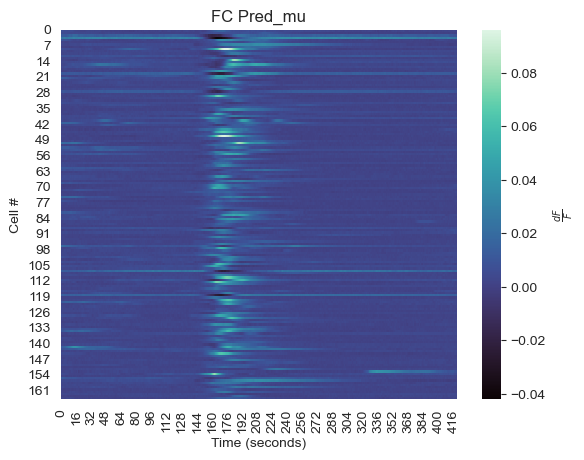

In [71]:
fig, ax = plt.subplots()
sns.heatmap(across_eta_fc_sorted, cmap='mako',cbar=True, cbar_kws={"label": r"$\frac{dF}{F}$"})
# ax.set_xticks(np.linspace(0, len(across_eta.T), 5), time)
ax.set_title('FC Pred_mu')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')